In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [17]:
fname = 'Morph2_result_summary.txt'

df = pd.read_csv(fname,delimiter='\t')
df.set_index('Code',inplace=True)
new_ID = ['Original', '3D', 'Semi3D', 'BotNeck3D', '+Layer', 'B4', 'B32', 'H32', 'H64',
'5to1', '3to1', '2to1', '1to1',
'30m', '30m (+Layer)', '30m (split)', '30m (H32)', '3D (B4H8)', '3D (B32H8)',
'3D (B16H32)','30m (split-com)']
df['ID']=new_ID
fig = []
df

,ID,BCE loss,Accuracy,Precision,Recall,F1 Score,CSI Score
Code,,,,,,,
0,Original,0.254,0.900,0.537,0.871,0.664,0.497
1,3D,0.145,0.933,0.681,0.776,0.725,0.569
2,Semi3D,0.167,0.923,0.620,0.831,0.709,0.550
3,BotNeck3D,0.424,0.823,0.385,0.948,0.548,0.377
4,+Layer,0.177,0.921,0.627,0.753,0.684,0.520
5,B4,0.179,0.916,0.593,0.841,0.695,0.533
6,B32,5.380,0.628,0.233,0.992,0.378,0.233
7,H32,0.167,0.922,0.613,0.833,0.706,0.546
8,H64,87.200,0.123,0.114,0.998,0.205,0.114


In [18]:
def plot_bar(df,title,benchmark,label=None):
    """""
    df = dataframe of model result
    title = string, figure title 
    benchmark = 1 row dataframe of benchmark data 
    label = list of string, label for x axis (default None = use ID column for name)
    """""
    fig,ax = plt.subplots(figsize=(len(df)*1.5,4))
    x = np.arange(len(df))*1.2
    width = 0.29
    # alpha = np.ones(len(x)).astype('float')
    # print(alpha)
    alpha = 1
    bars1 = plt.bar(x=x-width-0.01,height=df['Recall'],color='cornflowerblue',alpha=alpha,width=width,label='Recall')
    bars2 = plt.bar(x=x,height=df['F1 Score'],color='limegreen',alpha=alpha,width=width,label='F1 Score')
    bars3 = plt.bar(x=x+width+0.01,height=df['CSI Score'],color='tomato',alpha=alpha,width=width,label='CSI Score')

    for bars in (bars1, bars2, bars3):
        bars[0].set_alpha(0.5)

    plt.axhline(benchmark['Recall'],linestyle="--",color="blue",label=f'Recall Benchmark ({benchmark.ID})')
    plt.axhline(benchmark['F1 Score'],linestyle="--",color="green",label=f'F1 Score Benchmark ({benchmark.ID})')
    plt.axhline(benchmark['CSI Score'],linestyle="--",color="red",label=f'CSI Score Benchmark ({benchmark.ID})')
    plt.ylim(0,1)
    plt.title(title)
    
    if label:
        plt.xticks(x, label)
    else:
        plt.xticks(x, df['ID'].str.replace(" ", "\n"))
    plt.legend(loc='upper left',ncol=2)
    ax.legend(
        bbox_to_anchor=(0.5, -0.13),
        loc='upper center',
        ncol=2
        )
    return


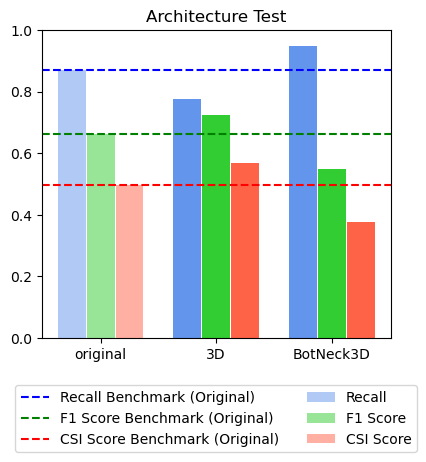

In [19]:
code = [0,1,3]
label = ['original','3D','BotNeck3D']
benchmark = df.loc[code[0]]
title = 'Architecture Test'
data = df.loc[code]
plot_bar(data,title,benchmark,label=label)

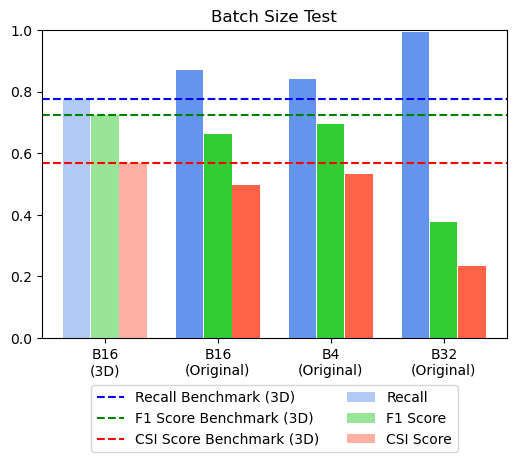

In [20]:
code = [1,0,5,6]
label = ['B16\n(3D)','B16\n(Original)','B4\n(Original)','B32\n(Original)']
benchmark = df.loc[code[0]]
title = 'Batch Size Test'
data = df.loc[code]
plot_bar(data,title,benchmark,label=label)

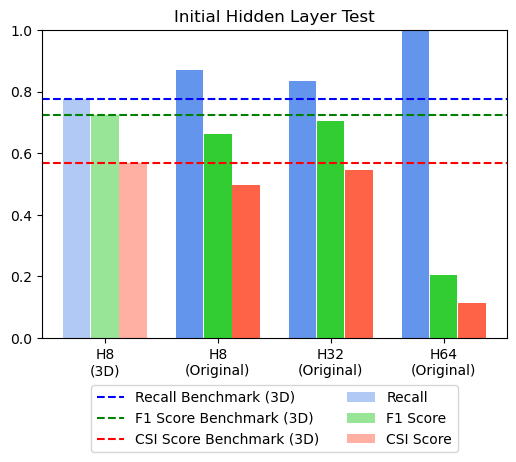

In [21]:
code = [1,0,7,8]
label = ['H8\n(3D)','H8\n(Original)','H32\n(Original)','H64\n(Original)']
benchmark = df.loc[code[0]]
title = 'Initial Hidden Layer Test'
data = df.loc[code]
plot_bar(data,title,benchmark,label=label)

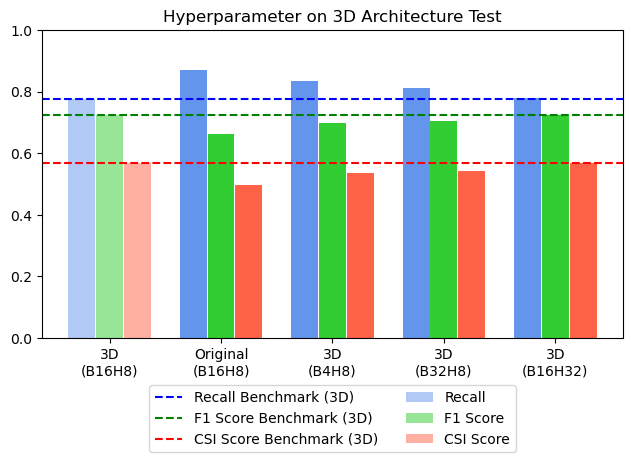

In [22]:
code = [1,0,17,18,19]
label = ['3D\n(B16H8)','Original\n(B16H8)','3D\n(B4H8)','3D\n(B32H8)', '3D\n(B16H32)']
benchmark = df.loc[code[0]]
title = 'Hyperparameter on 3D Architecture Test'
data = df.loc[code]
plot_bar(data,title,benchmark,label=label)

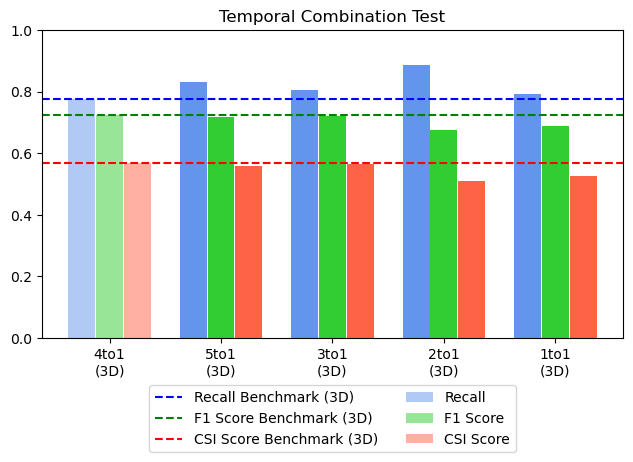

In [23]:
code = [1,9,10,11,12]
label = ['4to1\n(3D)','5to1\n(3D)','3to1\n(3D)','2to1\n(3D)', '1to1\n(3D)']
benchmark = df.loc[code[0]]
title = 'Temporal Combination Test'
data = df.loc[code]
plot_bar(data,title,benchmark,label=label)

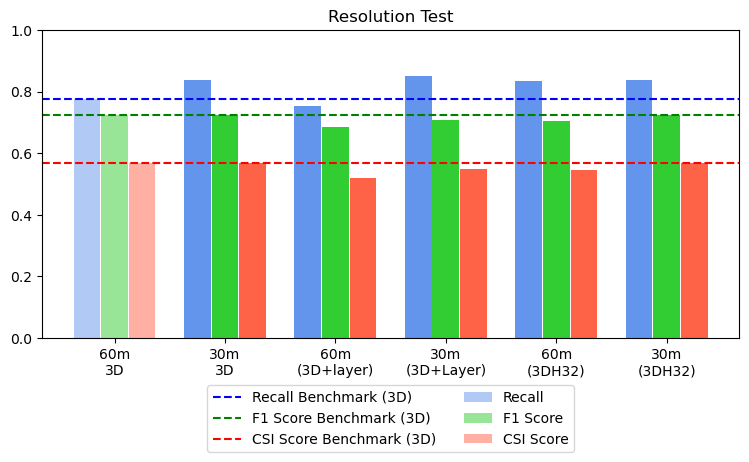

In [24]:
code = [1,13,4,14,7,16]
label = ['60m\n3D','30m\n3D','60m\n(3D+layer)','30m\n(3D+Layer)', '60m\n(3DH32)','30m\n(3DH32)']
benchmark = df.loc[code[0]]
title = 'Resolution Test'
data = df.loc[code]
plot_bar(data,title,benchmark,label=label)

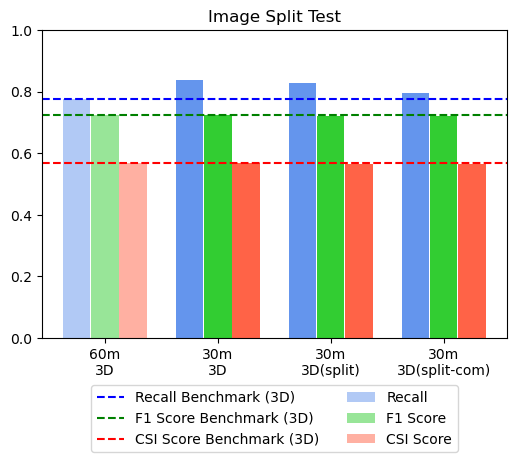

In [25]:
code = [1,13,15,20]
label = ['60m\n3D','30m\n3D','30m\n3D(split)','30m\n3D(split-com)']
benchmark = df.loc[code[0]]
title = 'Image Split Test'
data = df.loc[code]
plot_bar(data,title,benchmark,label=label)